<a href="https://colab.research.google.com/github/Pubudu-98/Colab/blob/main/Salary_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Gathering**

In [2]:
data = pd.read_csv('/content/Salary_Data.csv')

In [3]:
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


# **EDA (Exploritory Data Analysis)**

In [4]:
data.shape

(30, 2)

In [5]:
data.info

<bound method DataFrame.info of     YearsExperience  Salary
0               1.1   39343
1               1.3   46205
2               1.5   37731
3               2.0   43525
4               2.2   39891
5               2.9   56642
6               3.0   60150
7               3.2   54445
8               3.2   64445
9               3.7   57189
10              3.9   63218
11              4.0   55794
12              4.0   56957
13              4.1   57081
14              4.5   61111
15              4.9   67938
16              5.1   66029
17              5.3   83088
18              5.9   81363
19              6.0   93940
20              6.8   91738
21              7.1   98273
22              7.9  101302
23              8.2  113812
24              8.7  109431
25              9.0  105582
26              9.5  116969
27              9.6  112635
28             10.3  122391
29             10.5  121872>

In [6]:
# Check for unique values
data.nunique()

,0
YearsExperience,28
Salary,30


In [7]:
data.isnull().sum()

,0
YearsExperience,0
Salary,0


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.dtypes

,0
YearsExperience,float64
Salary,int64


# **Data Preprocessing**

In [10]:
# Seperating features (Independent and Dependent variables)
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

Now that we have separated our features (X) and target (y), we need to split the data into training and testing sets. This is crucial for evaluating how well our model generalizes to new, unseen data.

In [11]:
data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


The `data.describe()` output provides a summary of the central tendency, dispersion, and shape of the distribution of each numerical column. Now, let's visualize the relationship between 'YearsExperience' and 'Salary' to see if there's a clear pattern.

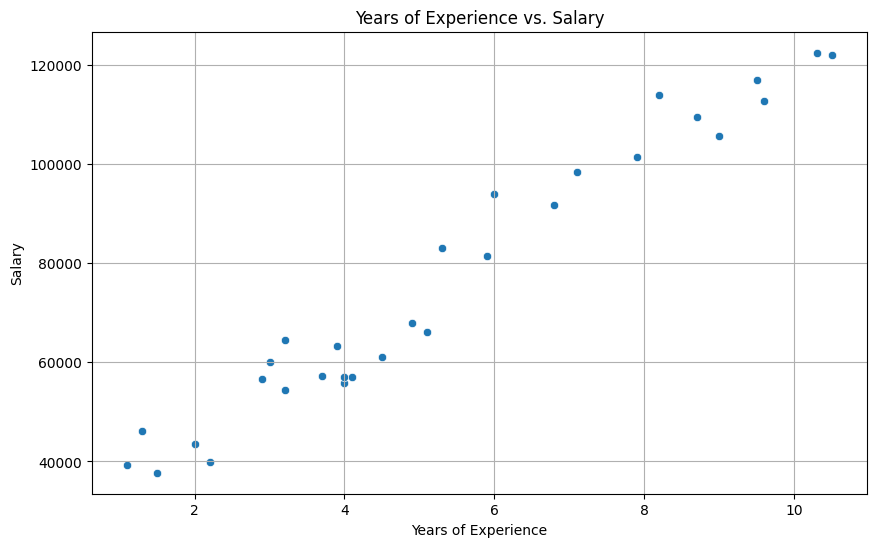

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=data)
plt.title('Years of Experience vs. Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

To split the data into training and testing sets, I need to import the `train_test_split` function from `sklearn.model_selection` and then apply it to `x` and `y` with the specified `test_size` and `random_state`.



In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

To train a linear regression model, I need to import the LinearRegression class from sklearn.linear_model, create an instance of it, and then fit it to the training data (x_train and y_train).



In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

print('The Linear Regression (lr) model has train successfully!')

The Linear Regression (lr) model has train successfully!


Now that the linear regression model has been trained, the next step is to make predictions on the test set (`x_test`) to see how well the model generalizes to unseen data.



In [15]:
y_pred = lr.predict(x_test)
print('Predictions on the test set have been saved!')

Predictions on the test set have been saved!


To evaluate the model's performance, I need to import the necessary metrics (MAE, MSE, R-squared) from `sklearn.metrics`.



In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Metrics imported successfully.")

Metrics imported successfully.


Now that the necessary metrics are imported, I will calculate the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared score between the actual and predicted values. Then, I will print these calculated metrics to evaluate the model's performance. After that, I will generate a scatter plot comparing the actual `y_test` values against the predicted `y_pred` values, including a diagonal line for perfect predictions, and add appropriate labels and a title to visualize the model's accuracy.



In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [19]:
print('MAE: ', round(mae, 2))
print('MSE: ', round(mse, 2))
print('R2 Score: ', round(r2, 2))

MAE:  6286.45
MSE:  49830096.86
R2 Score:  0.9


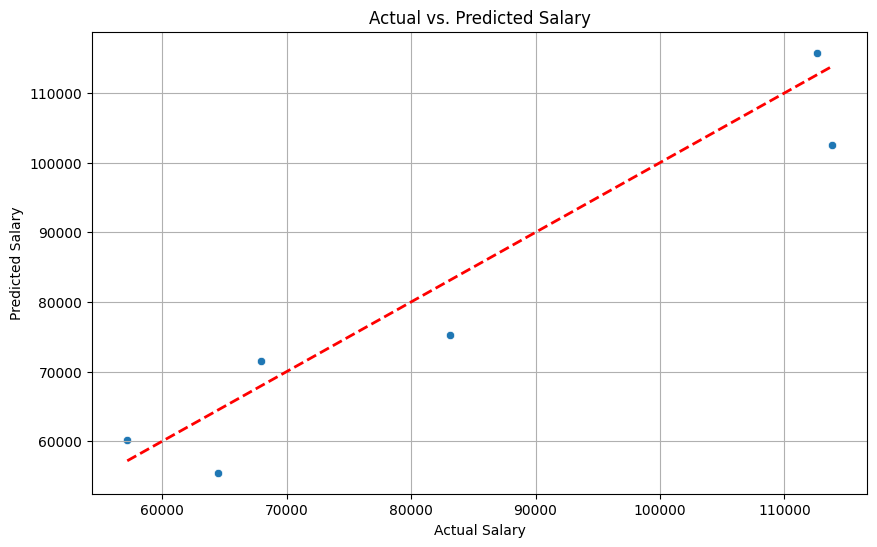

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Salary')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.grid(True)
plt.show()

In [21]:
print('Predicted Salaries (y_pred):')
print(y_pred)

Predicted Salaries (y_pred):
[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


### Data Analysis Key Findings

*   The data was successfully split into training (80%) and testing (20%) sets using a `random_state` of 42 for reproducibility.
*   A linear regression model was trained to predict `Salary` based on `YearsExperience`.
*   The model's performance on the test set was evaluated using several metrics:
    *   **Mean Absolute Error (MAE):** \$6286.45. This indicates that, on average, the model's predictions deviate by approximately \$6286.45 from the actual salary.
    *   **Mean Squared Error (MSE):** \$49,830,096.86. This metric penalizes larger errors more heavily.
    *   **R-squared (R2) Score:** 0.90. This suggests that 90% of the variance in salary can be explained by the `YearsExperience` feature, indicating a strong fit.
*   A scatter plot visualizing actual versus predicted salaries showed a strong linear relationship, with most points closely clustered around the perfect prediction line.

### Insights or Next Steps

*   The linear regression model demonstrates a strong capability to predict salary based on years of experience, as indicated by the high R-squared score of 0.90. The relatively low MAE suggests that the predictions are quite close to the actual values on average.
*   Consider exploring other features that might influence salary (e.g., education level, industry, location) to potentially improve the model's accuracy further, or investigate if more complex models could capture non-linear relationships if they exist.
